# California Multi-Temporal Remote Sensing Change Detection for Vegetation Stress Monitoring

## Objective
This notebook analyzes multi-temporal vegetation index data in California and explores whether abnormal vegetation stress periods can be detected through time series analysis.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Generate Simulated Vegetation Index Time Series

In [8]:
# Set random seed for reproducibility
np.random.seed(42)

# Create a monthly date range
dates = pd.date_range(start="2018-01-01", end="2024-12-31", freq="ME")

# Create a seasonal vegetation signal
seasonal_pattern = 0.15 * np.sin(2 * np.pi * np.arange(len(dates)) / 12)

# Create a slowly changing baseline
baseline = 0.6 + 0.01 * np.linspace(0, 1, len(dates))

# Add random noise
noise = np.random.normal(0, 0.03, len(dates))

# Simulate vegetation index
ndvi = baseline + seasonal_pattern + noise

# Introduce an abnormal stress period
stress_start = 45
stress_end = 52
ndvi[stress_start:stress_end] -= 0.18

# Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "ndvi": ndvi
})

df["rolling_mean"] = df["ndvi"].rolling(window=6, center=True).mean()
df.head()

,date,ndvi,rolling_mean
0,2018-01-31,0.614901,NaN
1,2018-02-28,0.670973,NaN
2,2018-03-31,0.749575,NaN
3,2018-04-30,0.796052,0.703907
4,2018-05-31,0.723361,0.709440


## Visualize the Time Series

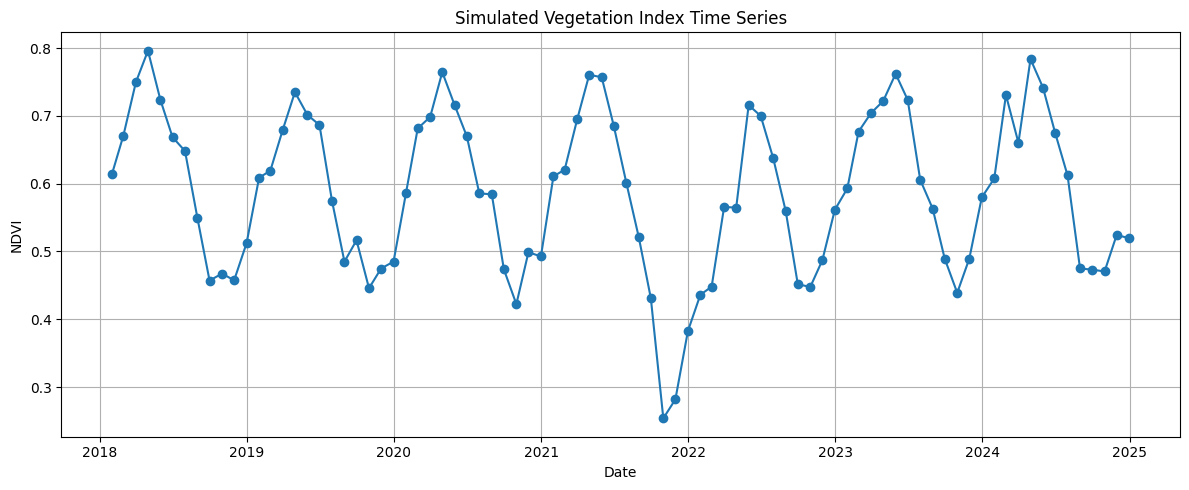

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["ndvi"], marker="o", linewidth=1.5)
plt.title("Simulated Vegetation Index Time Series")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/simulated_ndvi_timeseries.png", dpi=300)
plt.show()

## Rolling Mean for Trend Smoothing

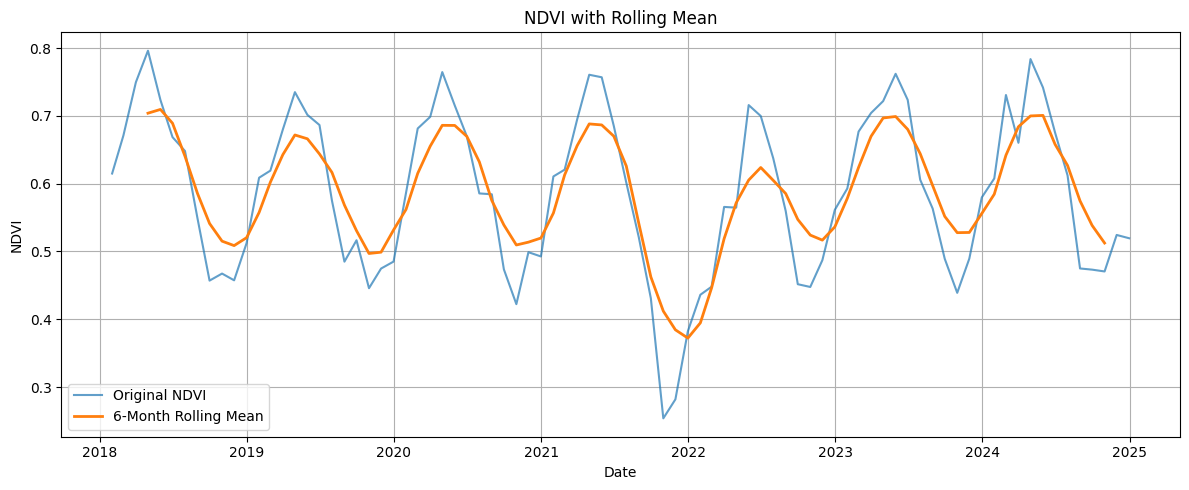

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["ndvi"], label="Original NDVI", alpha=0.7)
plt.plot(df["date"], df["rolling_mean"], label="6-Month Rolling Mean", linewidth=2)
plt.title("NDVI with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/ndvi_rolling_mean.png", dpi=300)
plt.show()

## Anomaly Detection with Z-Score

In [9]:
mean_ndvi = df["ndvi"].mean()
std_ndvi = df["ndvi"].std()

df["z_score"] = (df["ndvi"] - mean_ndvi) / std_ndvi

df.head()

,date,ndvi,rolling_mean,z_score
0,2018-01-31,0.614901,NaN,0.236694
1,2018-02-28,0.670973,NaN,0.709872
2,2018-03-31,0.749575,NaN,1.373195
3,2018-04-30,0.796052,0.703907,1.765409
4,2018-05-31,0.723361,0.709440,1.151975


In [10]:
threshold = -1.5
df["stress_flag"] = df["z_score"] < threshold

df[df["stress_flag"]]

,date,ndvi,rolling_mean,z_score,stress_flag
45,2021-10-31,0.253826,0.411967,-2.810384,True
46,2021-11-30,0.281819,0.384384,-2.574155,True
47,2021-12-31,0.382376,0.372195,-1.725564,True


## Highlight Detected Stress Periods

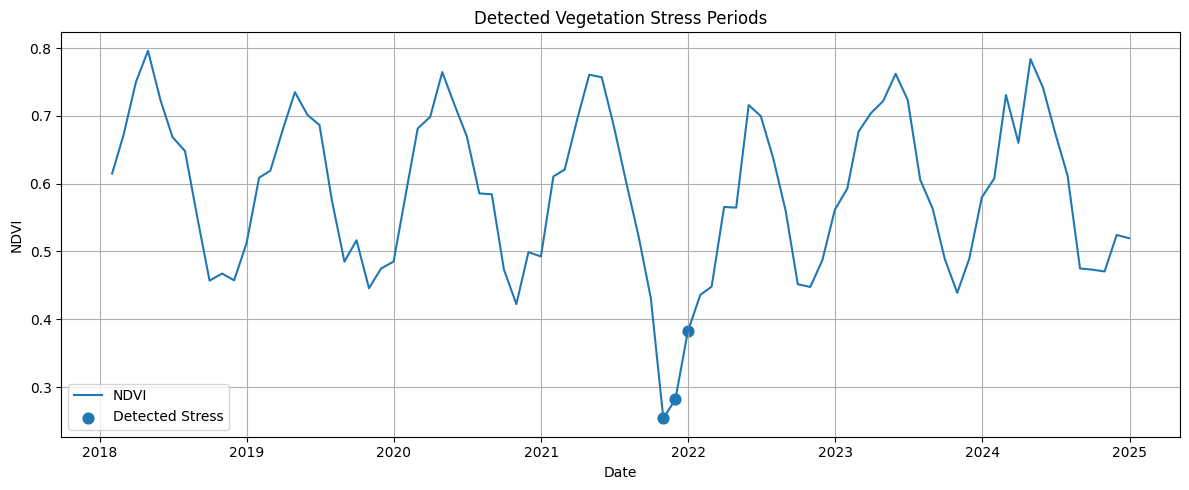

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["ndvi"], label="NDVI", linewidth=1.5)
plt.scatter(
    df.loc[df["stress_flag"], "date"],
    df.loc[df["stress_flag"], "ndvi"],
    label="Detected Stress",
    s=60
)
plt.title("Detected Vegetation Stress Periods")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/detected_stress_periods.png", dpi=300)
plt.show()

## Initial Interpretation

The simulated vegetation index series shows clear seasonal variation, moderate noise, and an abnormal stress period.  
Using a simple z-score threshold, several low-value observations were flagged as potential vegetation stress events.  
This demonstrates a basic workflow for change detection in multi-temporal environmental data.

## Save Figures

## Summary

In this first prototype, I created a simulated multi-temporal vegetation index time series to test a basic environmental change detection workflow.  
The analysis included trend visualization, rolling mean smoothing, and anomaly detection using z-scores.  
Several low-value observations were successfully flagged as potential vegetation stress periods.  

This prototype establishes the core analytical framework for the project.  
The next step is to replace the simulated series with real California remote sensing vegetation data and evaluate whether the same workflow can detect meaningful environmental stress patterns.

## Load NDVI Data from CSV

In [12]:
real_df = pd.read_csv("../data/california_ndvi_sample.csv")
real_df["date"] = pd.to_datetime(real_df["date"])
real_df.head()

,date,ndvi
0,2018-01-31,0.58
1,2018-02-28,0.60
2,2018-03-31,0.64
3,2018-04-30,0.69
4,2018-05-31,0.72


In [14]:
real_df["rolling_mean"] = real_df["ndvi"].rolling(window=6, center=True).mean()

mean_ndvi = real_df["ndvi"].mean()
std_ndvi = real_df["ndvi"].std()

real_df["z_score"] = (real_df["ndvi"] - mean_ndvi) / std_ndvi

threshold = -1.2
real_df["stress_flag"] = real_df["z_score"] < threshold

real_df.head()

,date,ndvi,rolling_mean,z_score,stress_flag
0,2018-01-31,0.58,NaN,-0.677350,False
1,2018-02-28,0.60,NaN,-0.393572,False
2,2018-03-31,0.64,NaN,0.173983,False
3,2018-04-30,0.69,0.661667,0.883427,False
4,2018-05-31,0.72,0.683333,1.309093,False


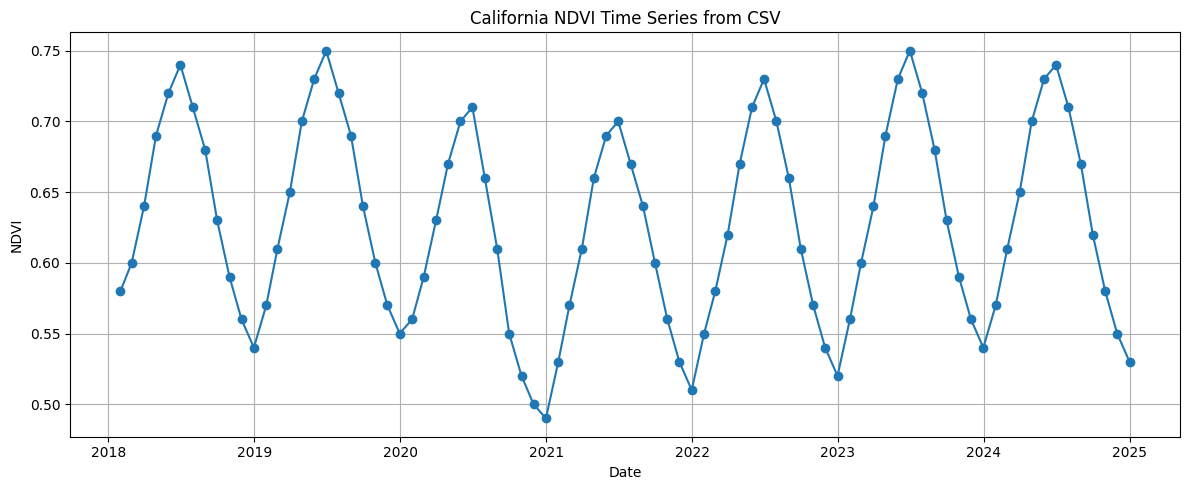

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(real_df["date"], real_df["ndvi"], marker="o", linewidth=1.5)
plt.title("California NDVI Time Series from CSV")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(True)
plt.tight_layout()
plt.show()

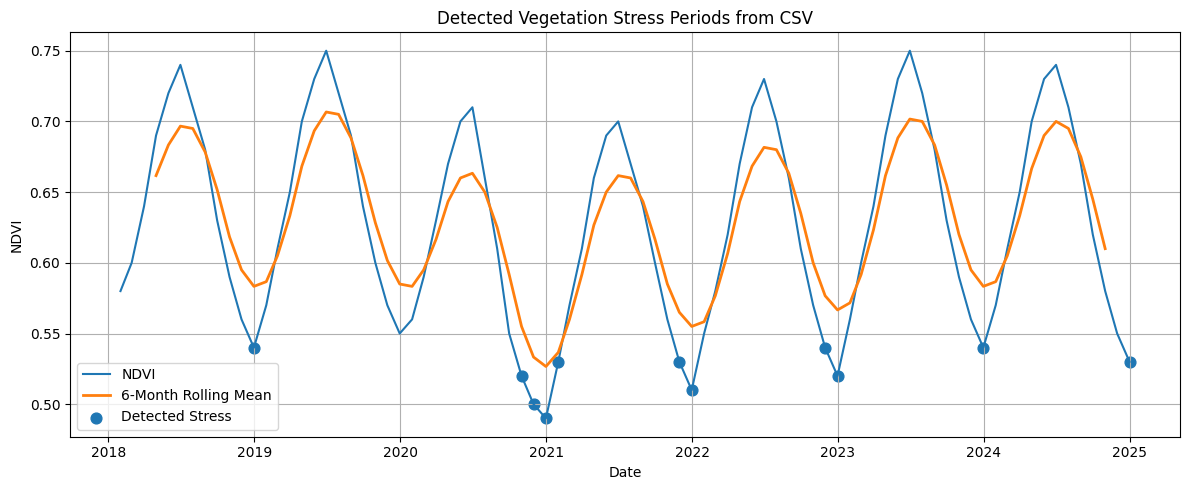

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(real_df["date"], real_df["ndvi"], label="NDVI", linewidth=1.5)
plt.plot(real_df["date"], real_df["rolling_mean"], label="6-Month Rolling Mean", linewidth=2)

plt.scatter(
    real_df.loc[real_df["stress_flag"], "date"],
    real_df.loc[real_df["stress_flag"], "ndvi"],
    label="Detected Stress",
    s=60
)

plt.title("Detected Vegetation Stress Periods from CSV")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/csv_detected_stress_periods.png", dpi=300)
plt.show()

## Interpretation of CSV-Based Analysis

This step replaces the fully simulated time series with a file-based NDVI dataset in CSV format.  
The same workflow — visualization, rolling mean smoothing, and z-score anomaly detection — can now be applied to data loaded from disk.  
This is an important transition from prototype testing to a reproducible analysis pipeline for environmental time series analysis.

## Build Reusable Functions

In [17]:
def load_ndvi_data(file_path):
    df = pd.read_csv(file_path)
    df["date"] = pd.to_datetime(df["date"])
    return df


def compute_metrics(df, window=6, threshold=-1.2):
    df = df.copy()
    df["rolling_mean"] = df["ndvi"].rolling(window=window, center=True).mean()

    mean_ndvi = df["ndvi"].mean()
    std_ndvi = df["ndvi"].std()

    df["z_score"] = (df["ndvi"] - mean_ndvi) / std_ndvi
    df["stress_flag"] = df["z_score"] < threshold

    return df


def plot_stress_detection(df, title="Detected Vegetation Stress Periods"):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["ndvi"], label="NDVI", linewidth=1.5)
    plt.plot(df["date"], df["rolling_mean"], label="6-Month Rolling Mean", linewidth=2)

    plt.scatter(
        df.loc[df["stress_flag"], "date"],
        df.loc[df["stress_flag"], "ndvi"],
        label="Detected Stress",
        s=60
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def save_stress_plot(df, save_path, title="Detected Vegetation Stress Periods"):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["ndvi"], label="NDVI", linewidth=1.5)
    plt.plot(df["date"], df["rolling_mean"], label="6-Month Rolling Mean", linewidth=2)

    plt.scatter(
        df.loc[df["stress_flag"], "date"],
        df.loc[df["stress_flag"], "ndvi"],
        label="Detected Stress",
        s=60
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

In [18]:
csv_df = load_ndvi_data("../data/california_ndvi_sample.csv")
csv_df = compute_metrics(csv_df, window=6, threshold=-1.2)
csv_df.head()

,date,ndvi,rolling_mean,z_score,stress_flag
0,2018-01-31,0.58,NaN,-0.677350,False
1,2018-02-28,0.60,NaN,-0.393572,False
2,2018-03-31,0.64,NaN,0.173983,False
3,2018-04-30,0.69,0.661667,0.883427,False
4,2018-05-31,0.72,0.683333,1.309093,False


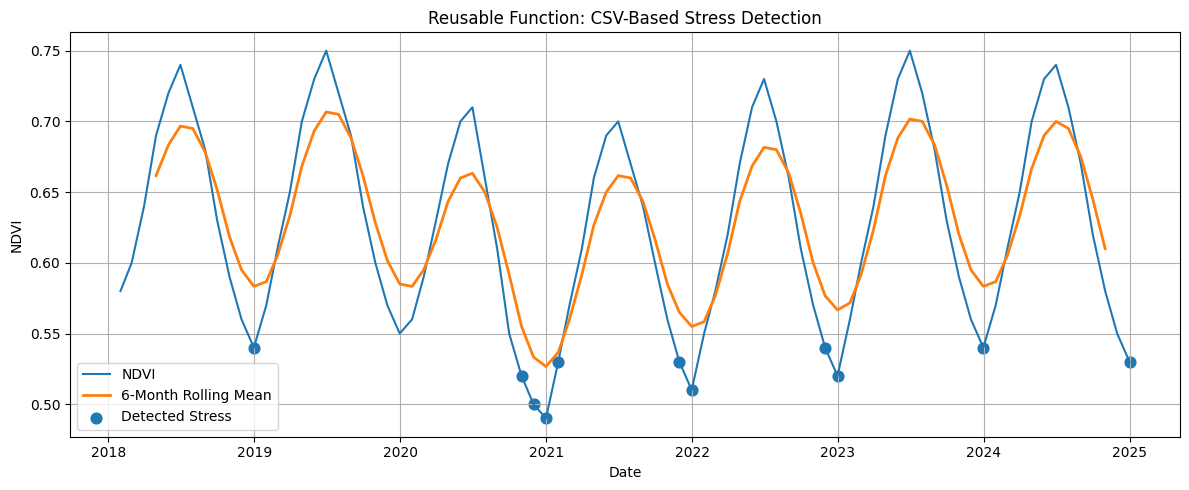

In [19]:
plot_stress_detection(csv_df, title="Reusable Function: CSV-Based Stress Detection")

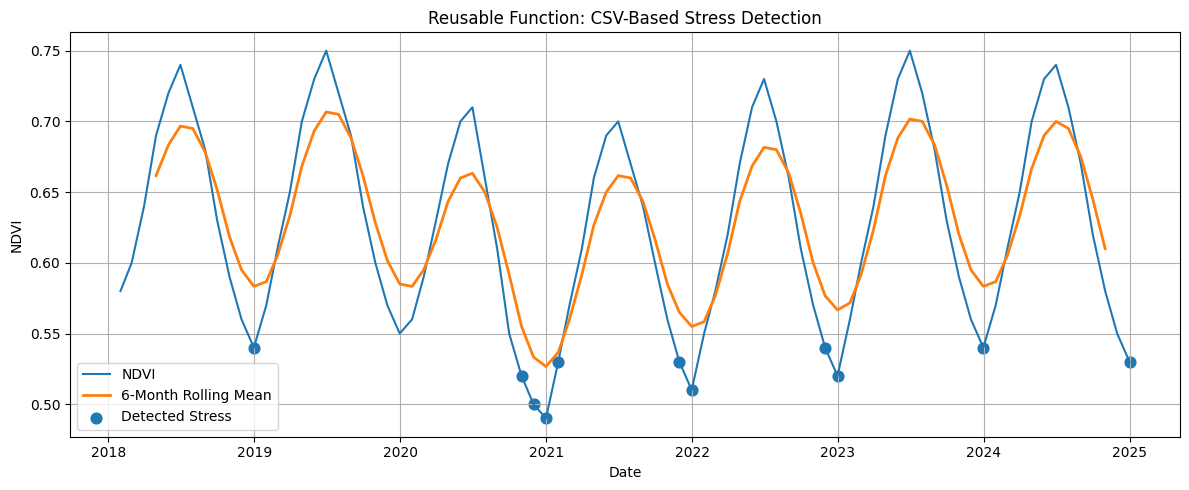

In [20]:
save_stress_plot(
    csv_df,
    "../figures/reusable_csv_stress_detection.png",
    title="Reusable Function: CSV-Based Stress Detection"
)

## Multi-Region California NDVI Comparison

In [22]:
multi_df = pd.read_csv("../data/california_ndvi_multiregion.csv")
multi_df["date"] = pd.to_datetime(multi_df["date"])
multi_df.head()

,date,region,ndvi
0,2018-01-31,North,0.62
1,2018-02-28,North,0.64
2,2018-03-31,North,0.68
3,2018-04-30,North,0.73
4,2018-05-31,North,0.76


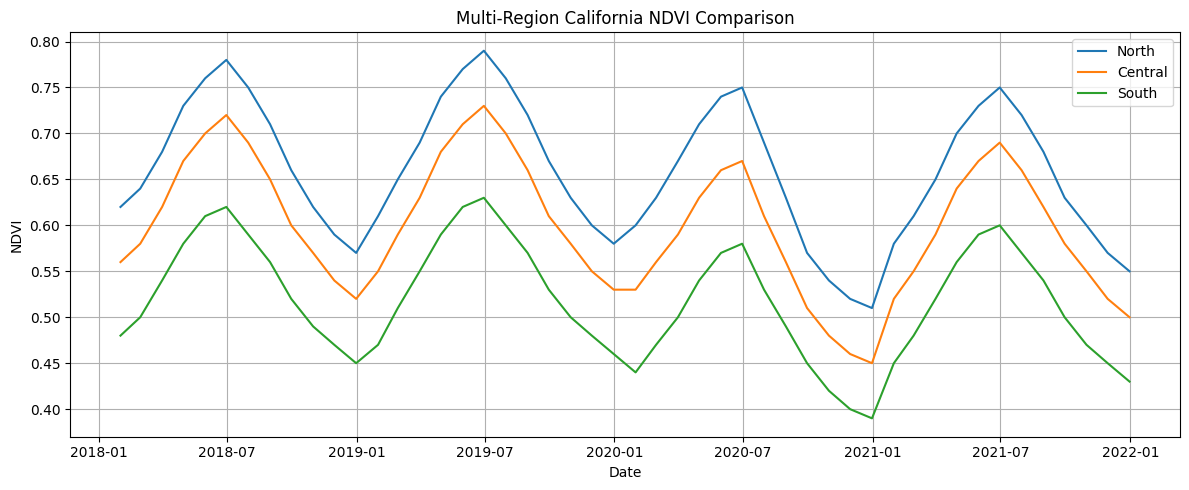

In [23]:
plt.figure(figsize=(12, 5))

for region in multi_df["region"].unique():
    subset = multi_df[multi_df["region"] == region]
    plt.plot(subset["date"], subset["ndvi"], label=region)

plt.title("Multi-Region California NDVI Comparison")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
def compute_metrics_by_region(df, window=6, threshold=-1.2):
    result = []

    for region in df["region"].unique():
        subset = df[df["region"] == region].copy()
        subset["rolling_mean"] = subset["ndvi"].rolling(window=window, center=True).mean()

        mean_ndvi = subset["ndvi"].mean()
        std_ndvi = subset["ndvi"].std()

        subset["z_score"] = (subset["ndvi"] - mean_ndvi) / std_ndvi
        subset["stress_flag"] = subset["z_score"] < threshold

        result.append(subset)

    return pd.concat(result, ignore_index=True)

In [25]:
multi_result = compute_metrics_by_region(multi_df, window=6, threshold=-1.2)
multi_result.head()

,date,region,ndvi,rolling_mean,z_score,stress_flag
0,2018-01-31,North,0.62,NaN,-0.528706,False
1,2018-02-28,North,0.64,NaN,-0.260157,False
2,2018-03-31,North,0.68,NaN,0.276941,False
3,2018-04-30,North,0.73,0.701667,0.948315,False
4,2018-05-31,North,0.76,0.723333,1.351139,False


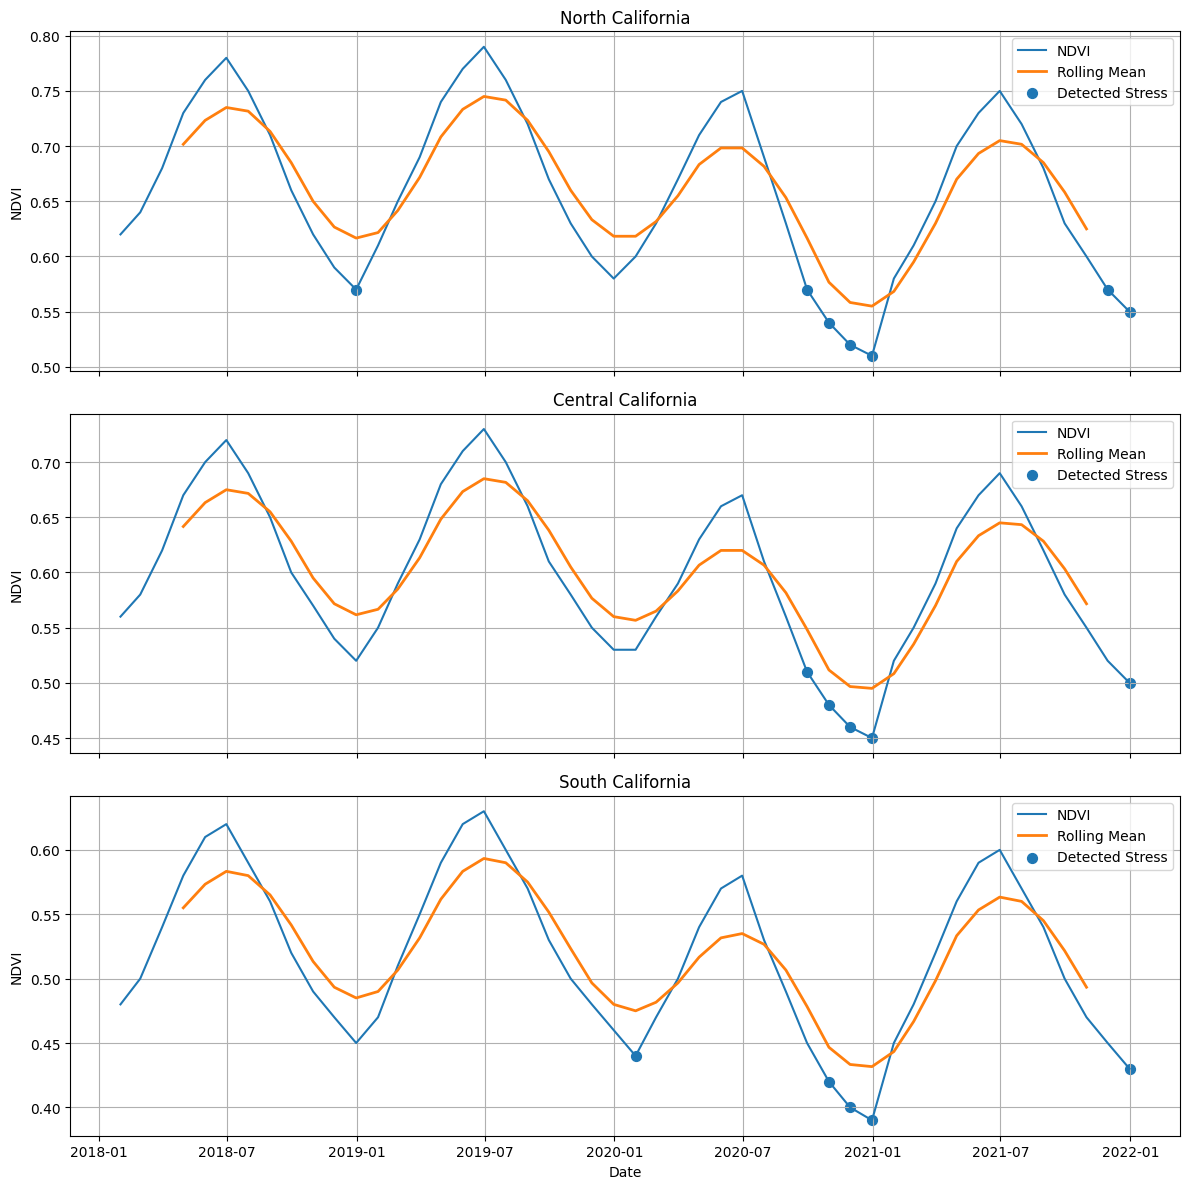

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

regions = multi_result["region"].unique()

for ax, region in zip(axes, regions):
    subset = multi_result[multi_result["region"] == region]

    ax.plot(subset["date"], subset["ndvi"], label="NDVI", linewidth=1.5)
    ax.plot(subset["date"], subset["rolling_mean"], label="Rolling Mean", linewidth=2)

    ax.scatter(
        subset.loc[subset["stress_flag"], "date"],
        subset.loc[subset["stress_flag"], "ndvi"],
        label="Detected Stress",
        s=50
    )

    ax.set_title(f"{region} California")
    ax.set_ylabel("NDVI")
    ax.grid(True)
    ax.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../figures/multiregion_stress_detection.png", dpi=300)
plt.show()

In [27]:
region_summary = multi_result.groupby("region")["stress_flag"].sum().reset_index()
region_summary.columns = ["region", "detected_stress_count"]
region_summary

,region,detected_stress_count
0,Central,5
1,North,7
2,South,5


## Interpretation of Multi-Region Results

The multi-region comparison shows that vegetation dynamics differ across California.  
Northern California has a generally higher NDVI baseline, while Southern California has lower baseline vegetation conditions.  
The detected stress periods also vary by region, suggesting that environmental stress is not spatially uniform.  

This extension makes the project more realistic by moving from a single time series to a simple regional comparison framework.

## Regional Summary Statistics

In [28]:
region_summary = multi_result.groupby("region").agg(
    mean_ndvi=("ndvi", "mean"),
    min_ndvi=("ndvi", "min"),
    max_ndvi=("ndvi", "max"),
    detected_stress_count=("stress_flag", "sum")
).reset_index()

region_summary

,region,mean_ndvi,min_ndvi,max_ndvi,detected_stress_count
0,Central,0.598750,0.45,0.73,5
1,North,0.659375,0.51,0.79,7
2,South,0.517917,0.39,0.63,5


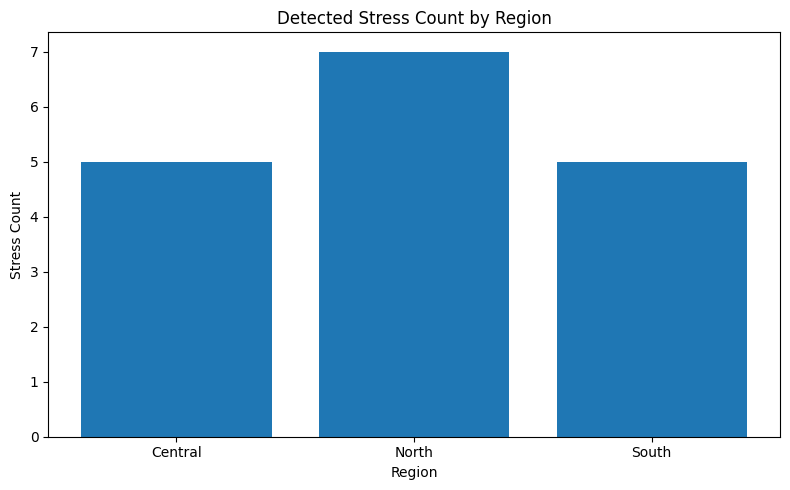

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(region_summary["region"], region_summary["detected_stress_count"])
plt.title("Detected Stress Count by Region")
plt.xlabel("Region")
plt.ylabel("Stress Count")
plt.tight_layout()
plt.savefig("../figures/stress_count_by_region.png", dpi=300)
plt.show()

## Interpretation of Multi-Region Results

The multi-region analysis reveals clear spatial differences in vegetation dynamics across California.

- Northern California shows the highest NDVI baseline, indicating relatively stronger vegetation conditions.
- Central California has intermediate vegetation levels but still exhibits several stress periods.
- Southern California has the lowest NDVI baseline and more pronounced low-value periods, suggesting greater environmental stress vulnerability.

Across all three regions, a notable decline appears around late 2020 to early 2021.  
This suggests that environmental stress is not only temporal but also spatially heterogeneous.

This extension improves the project by moving from a single time series to a regional comparison framework, which is closer to real environmental data science applications.

## Final Project Summary

This project developed a prototype workflow for multi-temporal vegetation stress detection in California.

The analysis progressed through several stages:
1. validating the detection workflow on simulated NDVI data,
2. applying the same method to file-based CSV data,
3. modularizing the workflow with reusable functions,
4. extending the analysis to multiple California regions.

Key findings include:
- Northern California has the highest average NDVI baseline.
- Southern California has the lowest vegetation baseline and the lowest minimum NDVI.
- Stress periods are detected in all three regions, especially around late 2020 to early 2021.
- Regional differences suggest that environmental stress is spatially heterogeneous, and threshold-based anomaly detection may behave differently across regions.

This project provides a foundation for future work using more realistic California environmental or remote sensing datasets.

## Real Remote Sensing Data: MODIS NDVI from California Fixed Site

In [31]:
import io
import requests
import pandas as pd
import numpy as np

In [32]:
# ORNL DAAC fixed-site API for a California MODIS NDVI subset
api_url = (
    "https://modis.ornl.gov/rst/api/v1/MOD13Q1/"
    "us_california_ussl_san_joaquin_almond_high/"
    "subsetFiltered?startDate=A2018001&endDate=A2021365"
)

response = requests.get(api_url, headers={"Accept": "text/csv"})
response.raise_for_status()

raw_df = pd.read_csv(io.StringIO(response.text), header=None)
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1084,1085,1086,1087,1088,1089,1090,1091,1092,1093
0,MOD13Q1.A2018001.h08v05.006.2021313023627.250m...,MOD13Q1,A2018001,Lat36.169669Lon-120.201004Samp33Line33,2021313023627,F,F,F,F,F,...,0.1372,0.1554,0.0919,0.0916,0.0669,0.1595,0.1415,0.1202,0.2013,0.2221
1,MOD13Q1.A2018001.h08v05.006.2021313023627.250m...,MOD13Q1,A2018001,Lat36.169669Lon-120.201004Samp33Line33,2021313023627,F,F,F,F,F,...,0.2662,0.2969,0.1931,0.1941,0.1379,0.3042,0.291,0.2533,0.3435,0.3724
2,MOD13Q1.A2018017.h08v05.006.2021314190743.250m...,MOD13Q1,A2018017,Lat36.169669Lon-120.201004Samp33Line33,2021314190743,0.2664,0.2694,0.2694,0.3018,0.2231,...,0.2714,0.2714,0.1542,0.1305,0.1236,0.1102,0.0812,0.0812,0.1140,0.1624
3,MOD13Q1.A2018017.h08v05.006.2021314190743.250m...,MOD13Q1,A2018017,Lat36.169669Lon-120.201004Samp33Line33,2021314190743,0.4892,0.5036,0.5036,0.4959,0.4325,...,0.4416,0.4416,0.2486,0.2166,0.1997,0.1826,0.1485,0.1485,0.1988,0.2784
4,MOD13Q1.A2018033.h08v05.006.2021317101955.250m...,MOD13Q1,A2018033,Lat36.169669Lon-120.201004Samp33Line33,2021317101955,0.2593,0.2839,0.2839,0.2834,0.2291,...,0.2976,0.2656,0.1150,0.1537,0.1034,0.0672,0.0628,0.0868,0.1349,0.1319


In [33]:
# Keep only NDVI rows
ndvi_rows = raw_df[raw_df[0].astype(str).str.contains("250m_16_days_NDVI", na=False)].copy()

# Pixel values start after metadata columns
pixel_cols = ndvi_rows.columns[5:]

# Convert MODIS composite date AYYYYDDD -> datetime
dates = pd.to_datetime(ndvi_rows[2].str.replace("A", "", regex=False), format="%Y%j")

# Convert pixel values to numeric, remove fill value, apply scale factor
pixel_values = ndvi_rows[pixel_cols].apply(pd.to_numeric, errors="coerce")
pixel_values = pixel_values.replace(-3000, np.nan) * 0.0001

# Mean NDVI over the subset for each date
modis_df = pd.DataFrame({
    "date": dates,
    "ndvi": pixel_values.mean(axis=1)
}).sort_values("date").reset_index(drop=True)

modis_df.head()

,date,ndvi
0,2018-01-01,0.000025
1,2018-01-17,0.000034
2,2018-02-02,0.000035
3,2018-02-18,0.000031
4,2018-03-06,0.000040


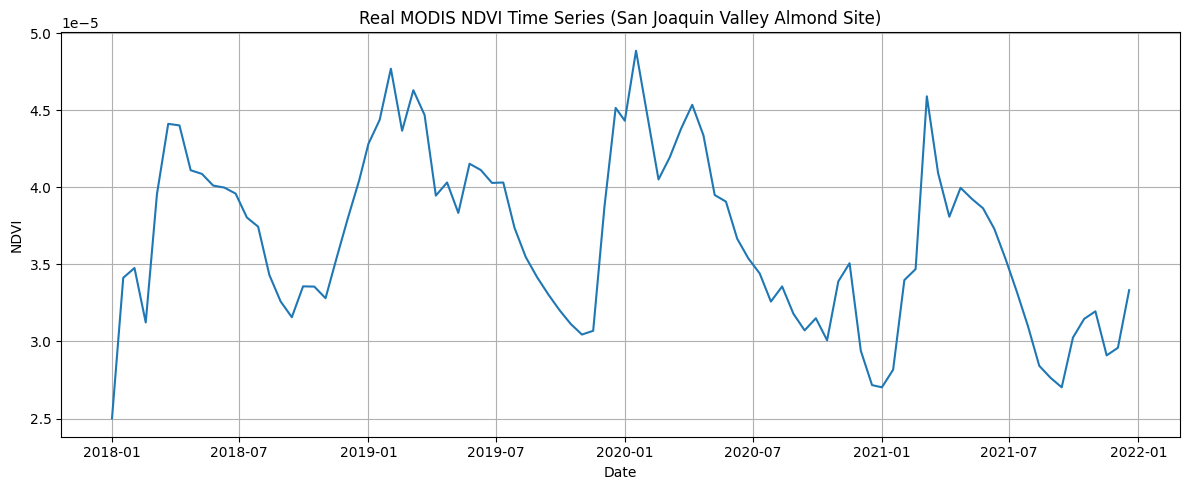

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(modis_df["date"], modis_df["ndvi"], linewidth=1.5)
plt.title("Real MODIS NDVI Time Series (San Joaquin Valley Almond Site)")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
modis_result = compute_metrics(modis_df, window=5, threshold=-1.2)
modis_result.head()

,date,ndvi,rolling_mean,z_score,stress_flag
0,2018-01-01,0.000025,NaN,-2.081583,True
1,2018-01-17,0.000034,NaN,-0.444118,False
2,2018-02-02,0.000035,0.000033,-0.330172,False
3,2018-02-18,0.000031,0.000037,-0.964230,False
4,2018-03-06,0.000040,0.000039,0.531300,False


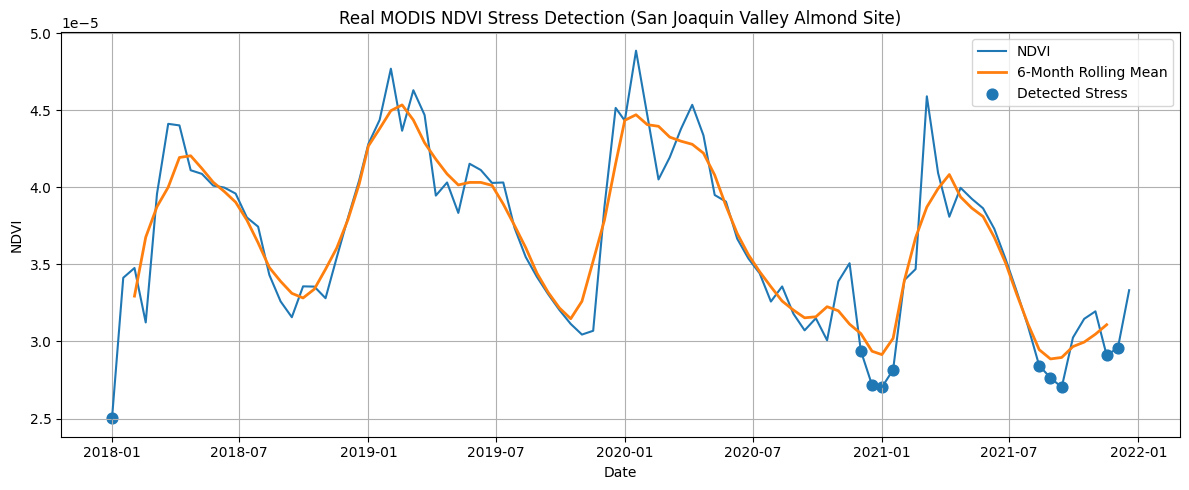

In [36]:
plot_stress_detection(
    modis_result,
    title="Real MODIS NDVI Stress Detection (San Joaquin Valley Almond Site)"
)

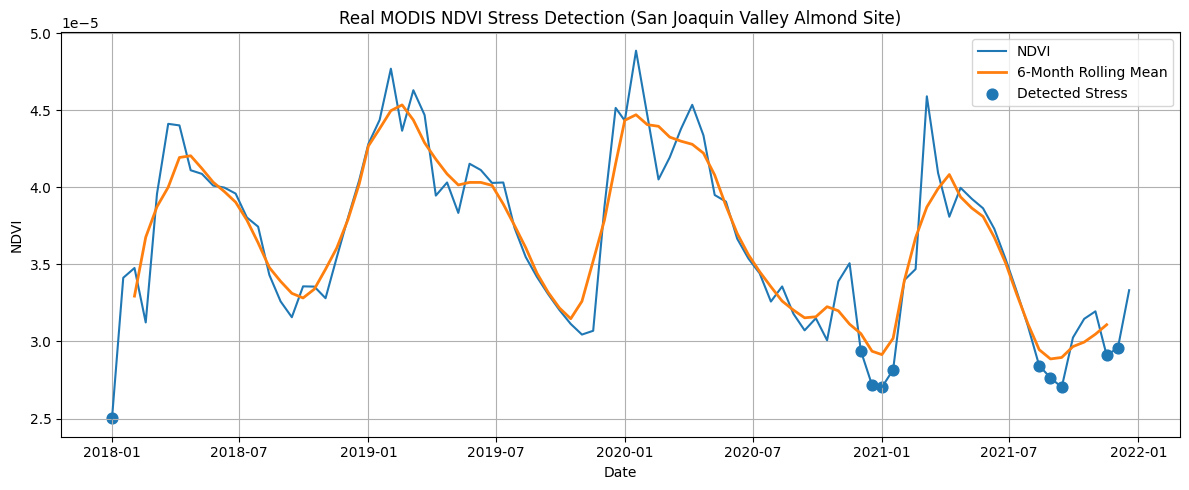

In [37]:
save_stress_plot(
    modis_result,
    "../figures/real_modis_stress_detection.png",
    title="Real MODIS NDVI Stress Detection (San Joaquin Valley Almond Site)"
)

## Interpretation of Real MODIS NDVI Analysis

This section replaces the prototype CSV with a real remote sensing time series from the MODIS/Terra MOD13Q1 vegetation index product.  
The workflow remains the same: load the data, aggregate the NDVI values over the site subset, smooth the series with a rolling mean, and detect potential vegetation stress periods using z-scores.

This is the first version of the project that uses a real satellite-derived vegetation product rather than simulated or manually prepared data.